# GNN Training Pipeline for Network Intrusion Detection

## Overview
This notebook implements a complete GNN training pipeline with:
- **Protocol-aware k-NN graph construction** (edges only within TCP/UDP/ICMP/Other groups)
- **Fixed label mapping** (8 multiclass + binary classification)
- **GNNExplainer-based interpretability**
- **Multiple data splits**: 70-15-15, 50-25-25, 20-40-40

## Pipeline Steps:
1. Import libraries and setup
2. Load and preprocess data with fixed label mapping
3. Build protocol-aware k-NN graph
4. Train multiclass models with 3 different splits
5. Train binary model (Benign vs Attack)
6. Run explainability analysis
7. Compare performance and generate diagnostics

## Section 1: Import Libraries and Setup

In [1]:
# Import required libraries
import os
import sys
import warnings
import importlib
import pickle
import json
from collections import Counter

import numpy as np
import pandas as pd
import scipy.sparse
import torch
import torch.nn as nn
import torch.optim as optim
import joblib

# Set random seeds for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True

# Device selection
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Suppress warnings
warnings.filterwarnings('ignore')

# Create organized output directories
CHECKPOINT_DIR = 'checkpoints/gnn_training'
MODEL_DIR_MULTICLASS = 'models/multiclass'
MODEL_DIR_BINARY = 'models/binary'

os.makedirs(MODEL_DIR_MULTICLASS, exist_ok=True)
os.makedirs(MODEL_DIR_BINARY, exist_ok=True)
os.makedirs('scalers', exist_ok=True)
os.makedirs('explanations', exist_ok=True)
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

print(f"\n✓ Created output directories:")
print(f"  - {MODEL_DIR_MULTICLASS}/")
print(f"  - {MODEL_DIR_BINARY}/")
print(f"  - scalers/")
print(f"  - explanations/")
print(f"  - {CHECKPOINT_DIR}/")

# Reload gnn_utils to pick up latest changes
if 'gnn_utils' in sys.modules:
    importlib.reload(sys.modules['gnn_utils'])
print("✓ Module management ready")

# Helper functions for checkpoint management
def save_checkpoint(name, data):
    """Save checkpoint data to disk."""
    path = os.path.join(CHECKPOINT_DIR, f"{name}.pkl")
    with open(path, 'wb') as f:
        pickle.dump(data, f)
    print(f"  ✓ Checkpoint saved: {path}")

def load_checkpoint(name):
    """Load checkpoint data from disk if exists."""
    path = os.path.join(CHECKPOINT_DIR, f"{name}.pkl")
    if os.path.exists(path):
        with open(path, 'rb') as f:
            data = pickle.load(f)
        print(f"  ✓ Checkpoint loaded: {path}")
        return data
    return None

def checkpoint_exists(name):
    """Check if a checkpoint exists."""
    path = os.path.join(CHECKPOINT_DIR, f"{name}.pkl")
    return os.path.exists(path)

print("✓ Checkpoint utilities ready")

Using device: cuda
GPU: NVIDIA GeForce RTX 3080 Ti
Memory: 12.5 GB

✓ Created output directories:
  - models/multiclass/
  - models/binary/
  - scalers/
  - explanations/
  - checkpoints/gnn_training/
✓ Module management ready
✓ Checkpoint utilities ready


In [2]:
# Import GNN utilities from gnn_utils.py
from gnn_utils import (
    # Label mappings
    LABEL_MAP,
    REVERSE_LABEL_MAP,
    BINARY_LABEL_MAP,
    REVERSE_BINARY_LABEL_MAP,
    encode_labels,
    decode_labels,
    get_label_map,
    
    # Data loading and preprocessing
    load_and_preprocess_gnn_data,
    create_train_val_test_masks,
    create_pyg_data,
    
    # Graph construction
    build_protocol_aware_knn_graph,
    build_knn_graph,
    
    # Models
    GraphSAGEModel,
    GATModel,
    
    # Training
    calculate_class_weights,
    train_gnn_with_early_stopping,
    evaluate_gnn,
    print_detailed_metrics,
    save_gnn_model,
    
    # High-level training pipelines
    train_gnn_multiclass,
    train_gnn_binary,
    
    # Explainability
    explain_node,
    explain_nodes_by_class,
    summarize_explanations,
    run_explainability,
)

print("✓ Imported all GNN utilities from gnn_utils.py")
print(f"\nLabel mapping (multiclass):")
for k, v in LABEL_MAP.items():
    print(f"  {k}: {v}")
print(f"\nBinary labels: {BINARY_LABEL_MAP}")

✓ Imported all GNN utilities from gnn_utils.py

Label mapping (multiclass):
  0: BFA
  1: BOTNET
  2: DDoS
  3: DoS
  4: Normal
  5: Probe
  6: U2R
  7: Web-Attack

Binary labels: {0: 'Benign', 1: 'Attack'}


## Section 2: Load and Preprocess Data

Load the balanced CTGAN dataset and preprocess for GNN training:
- Extract Protocol column for graph construction
- Encode labels using fixed LABEL_MAP
- Apply RobustScaler to features
- Handle NaN/inf values

In [3]:
# Load and preprocess data for multiclass training (with checkpoint support)
print("="*80)
print("LOADING AND PREPROCESSING DATA")
print("="*80)

# Path to training data
CSV_PATH = 'checkpoints/ctgan/balanced_20.csv'

# Check for existing checkpoint
if checkpoint_exists('multiclass_data'):
    print("\n📂 Loading from checkpoint...")
    ckpt = load_checkpoint('multiclass_data')
    X_scaled = ckpt['X_scaled']
    y_encoded = ckpt['y_encoded']
    protocols = ckpt['protocols']
    feature_names = ckpt['feature_names']
    label_map = ckpt['label_map']
    n_samples = X_scaled.shape[0]
    num_features = X_scaled.shape[1]
    num_classes = len(set(y_encoded))
else:
    print("\n🔄 Processing data from scratch...")
    # Load and preprocess (multiclass labels)
    X_scaled, y_encoded, scaler, protocols, feature_names, label_map = load_and_preprocess_gnn_data(
        CSV_PATH,
        scaler_path='scalers/gnn_scaler_multiclass.pkl',
        fit_scaler=True,
        binary_labels=False
    )
    
    # Store for later use
    n_samples = X_scaled.shape[0]
    num_features = X_scaled.shape[1]
    num_classes = len(set(y_encoded))
    
    # Save checkpoint
    save_checkpoint('multiclass_data', {
        'X_scaled': X_scaled,
        'y_encoded': y_encoded,
        'protocols': protocols,
        'feature_names': feature_names,
        'label_map': label_map
    })

print(f"\n✓ Data loaded successfully:")
print(f"  Samples: {n_samples:,}")
print(f"  Features: {num_features}")
print(f"  Classes: {num_classes}")
print(f"  Class distribution: {dict(Counter(y_encoded))}")

LOADING AND PREPROCESSING DATA

📂 Loading from checkpoint...
  ✓ Checkpoint loaded: checkpoints/gnn_training/multiclass_data.pkl

✓ Data loaded successfully:
  Samples: 464,770
  Features: 20
  Classes: 8
  Class distribution: {np.int64(0): 36798, np.int64(1): 36798, np.int64(2): 121942, np.int64(3): 53616, np.int64(4): 68424, np.int64(5): 73596, np.int64(6): 36798, np.int64(7): 36798}


## Section 3: Build Protocol-Aware k-NN Graph

Construct the graph with protocol awareness:
- Group flows by Protocol (TCP/UDP/ICMP/Other)
- Build k-NN graph (k=5) within each protocol group
- No edges cross protocol boundaries
- Merge all subgraphs into final edge_index

In [4]:
# Build protocol-aware k-NN graph (with checkpoint support)
print("="*80)
print("BUILDING PROTOCOL-AWARE K-NN GRAPH")
print("="*80)

# Check for existing checkpoint
if checkpoint_exists('multiclass_graph'):
    print("\n📂 Loading graph from checkpoint...")
    ckpt = load_checkpoint('multiclass_graph')
    edge_index = ckpt['edge_index']
else:
    print("\n🔄 Building graph from scratch...")
    # Build graph with protocol awareness
    edge_index = build_protocol_aware_knn_graph(X_scaled, protocols, k=5)
    
    # Save checkpoint
    save_checkpoint('multiclass_graph', {
        'edge_index': edge_index
    })

print(f"\n✓ Graph construction complete:")
print(f"  Nodes: {n_samples:,}")
print(f"  Edges: {edge_index.shape[1]:,}")
print(f"  Average degree: {edge_index.shape[1] / n_samples:.2f}")

BUILDING PROTOCOL-AWARE K-NN GRAPH

📂 Loading graph from checkpoint...
  ✓ Checkpoint loaded: checkpoints/gnn_training/multiclass_graph.pkl

✓ Graph construction complete:
  Nodes: 464,770
  Edges: 2,323,850
  Average degree: 5.00


## Section 4: Comprehensive 12-Model Training

Train all combinations:
- **Architectures**: GAT, GraphSAGE
- **Splits**: 70-15-15, 50-25-25, 20-40-40
- **Tasks**: Multiclass (8 classes), Binary (Benign vs Attack)

**Improved Hyperparameters**:
- Hidden dim: 128 (increased from 64)
- GAT heads: 4 (increased from 2)
- GraphSAGE layers: 3 (deeper)
- Learning rate: 5e-4 (more stable)
- Weight decay: 1e-4 (stronger regularization)
- Patience: 30 epochs

In [5]:
# ============================================================================
# COMPREHENSIVE 12-MODEL TRAINING PIPELINE
# ============================================================================

print("="*80)
print("TRAINING 12 GNN MODELS")
print("2 architectures (GAT, GraphSAGE) × 3 splits × 2 tasks (multiclass, binary)")
print("="*80)

# Aggressive GPU memory cleanup function
import gc

def clear_gpu_memory():
    """Aggressively clear GPU memory."""
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

# Initial cleanup
clear_gpu_memory()

# Configuration
SPLITS = {
    '70-15-15': (0.70, 0.15),
    '50-25-25': (0.50, 0.25),
    '20-40-40': (0.20, 0.40)
}

ARCHITECTURES = ['GAT', 'GraphSAGE']

# Hyperparameters - optimized for GPU memory (RTX 3080 Ti 12GB)
# Smaller models to fit in GPU memory with large graph
HYPERPARAMS = {
    'GAT': {
        'hidden_dim': 32,    # Reduced for GPU memory
        'heads': 2,          
        'dropout': 0.4,      
        'num_layers': 2,
    },
    'GraphSAGE': {
        'hidden_dim': 64,    # Reduced for GPU memory
        'dropout': 0.4,      
        'num_layers': 2      
    }
}

# Training settings
TRAINING_CONFIG = {
    'lr': 1e-3,              
    'weight_decay': 5e-4,    
    'num_epochs': 200,       
    'patience': 25,          
}

# Use GPU
training_device = device
print(f"\n✓ Using GPU for training: {torch.cuda.get_device_name(0)}")
print(f"  GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"  Dataset: {n_samples:,} nodes, {edge_index.shape[1]:,} edges")

# Store all results
all_results = {
    'multiclass': [],
    'binary': []
}

print(f"\nHyperparameters (optimized for GPU memory):")
print(f"  GAT: hidden_dim={HYPERPARAMS['GAT']['hidden_dim']}, heads={HYPERPARAMS['GAT']['heads']}, dropout={HYPERPARAMS['GAT']['dropout']}")
print(f"  GraphSAGE: hidden_dim={HYPERPARAMS['GraphSAGE']['hidden_dim']}, layers={HYPERPARAMS['GraphSAGE']['num_layers']}, dropout={HYPERPARAMS['GraphSAGE']['dropout']}")
print(f"\nTraining config:")
print(f"  LR={TRAINING_CONFIG['lr']}, weight_decay={TRAINING_CONFIG['weight_decay']}")
print(f"  max_epochs={TRAINING_CONFIG['num_epochs']}, patience={TRAINING_CONFIG['patience']}")

TRAINING 12 GNN MODELS
2 architectures (GAT, GraphSAGE) × 3 splits × 2 tasks (multiclass, binary)

✓ Using GPU for training: NVIDIA GeForce RTX 3080 Ti
  GPU Memory: 12.5 GB
  Dataset: 464,770 nodes, 2,323,850 edges

Hyperparameters (optimized for GPU memory):
  GAT: hidden_dim=32, heads=2, dropout=0.4
  GraphSAGE: hidden_dim=64, layers=2, dropout=0.4

Training config:
  LR=0.001, weight_decay=0.0005
  max_epochs=200, patience=25


### Part 1: Multiclass Models (6 models)

In [6]:
# ============================================================================
# PART 1: MULTICLASS MODELS (6 models: 2 architectures × 3 splits)
# ============================================================================

print("\n" + "="*80)
print("PART 1: TRAINING MULTICLASS MODELS (8 classes)")
print("="*80)

# Pre-compute data on CPU, move to GPU only during training
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_encoded, dtype=torch.long)
edge_tensor = edge_index.clone()

for arch in ARCHITECTURES:
    for split_name, (train_ratio, val_ratio) in SPLITS.items():
        model_name = f"gnn_{arch.lower()}_{split_name.replace('-', '_')}"
        model_path = os.path.join(MODEL_DIR_MULTICLASS, f"{model_name}.pt")
        
        print(f"\n{'='*60}")
        print(f"Training: {arch} - {split_name} (Multiclass)")
        print(f"{'='*60}")
        
        # Check for existing checkpoint
        ckpt_name = f"results_multiclass_{arch.lower()}_{split_name.replace('-', '_')}"
        
        if os.path.exists(model_path) and checkpoint_exists(ckpt_name):
            print(f"📂 Loading from checkpoint: {model_path}")
            ckpt = load_checkpoint(ckpt_name)
            results = ckpt['results']
            all_results['multiclass'].append(results)
            print(f"  Accuracy: {results['accuracy']:.4f}, F1: {results['f1']:.4f}")
            continue
        
        # Clear GPU before each model
        clear_gpu_memory()
        print(f"🔄 Training on GPU (mem free: {torch.cuda.memory_reserved(0)/1e9:.2f}GB reserved)")
        
        # Create masks
        train_mask, val_mask, test_mask = create_train_val_test_masks(
            n_samples, y_encoded, train_ratio=train_ratio, val_ratio=val_ratio
        )
        
        # Create data object and move to GPU
        data = create_pyg_data(X_scaled, y_encoded, edge_index, train_mask, val_mask, test_mask)
        data = data.to(training_device)
        
        # Calculate class weights
        y_train = y_encoded[train_mask]
        weights = calculate_class_weights(y_train)
        
        # Create model based on architecture
        hp = HYPERPARAMS[arch]
        if arch == 'GAT':
            model = GATModel(
                num_features=num_features,
                hidden_dim=hp['hidden_dim'],
                num_classes=num_classes,
                heads=hp['heads'],
                dropout=hp['dropout'],
                device=training_device
            )
        else:  # GraphSAGE
            model = GraphSAGEModel(
                num_features=num_features,
                hidden_dim=hp['hidden_dim'],
                num_classes=num_classes,
                dropout=hp['dropout'],
                num_layers=hp['num_layers'],
                device=training_device
            )
        
        # Setup training
        optimizer = optim.Adam(
            model.parameters(), 
            lr=TRAINING_CONFIG['lr'], 
            weight_decay=TRAINING_CONFIG['weight_decay']
        )
        criterion = nn.CrossEntropyLoss(weight=weights.to(training_device))
        
        # Train with early stopping
        best_model, history = train_gnn_with_early_stopping(
            model, data, optimizer, criterion, training_device,
            num_epochs=TRAINING_CONFIG['num_epochs'],
            patience=TRAINING_CONFIG['patience'],
            verbose=True
        )
        
        # Evaluate on test set
        test_metrics = evaluate_gnn(best_model, data, data.test_mask, training_device)
        
        # Move model to CPU for saving to free GPU memory
        best_model_cpu = best_model.to('cpu')
        
        # Save model (from CPU)
        save_gnn_model(
            best_model_cpu, model_path,
            metadata={
                'architecture': arch,
                'split': split_name,
                'task': 'multiclass',
                'test_f1': test_metrics['f1'],
                'test_accuracy': test_metrics['accuracy'],
                'num_features': num_features,
                'num_classes': num_classes,
                **hp
            },
            label_map=label_map
        )
        
        # Print metrics
        print(f"\n  Test Accuracy: {test_metrics['accuracy']:.4f}")
        print(f"  Test F1: {test_metrics['f1']:.4f}")
        print(f"  Test Precision: {test_metrics['precision']:.4f}")
        print(f"  Test Recall: {test_metrics['recall']:.4f}")
        
        # Store results
        results = {
            'architecture': arch,
            'split': split_name,
            'task': 'multiclass',
            'accuracy': test_metrics['accuracy'],
            'precision': test_metrics['precision'],
            'recall': test_metrics['recall'],
            'f1': test_metrics['f1']
        }
        all_results['multiclass'].append(results)
        
        # Save checkpoint
        save_checkpoint(ckpt_name, {
            'results': results,
            'test_metrics': {k: v for k, v in test_metrics.items() 
                           if k not in ['predictions', 'true_labels']}
        })
        
        print(f"✓ Saved: {model_path}")
        
        # AGGRESSIVE MEMORY CLEANUP
        del model, best_model, best_model_cpu, data, optimizer, criterion, weights
        del train_mask, val_mask, test_mask, test_metrics
        clear_gpu_memory()
        print(f"  Memory cleaned (GPU reserved: {torch.cuda.memory_reserved(0)/1e9:.2f}GB)")

# Clean up tensors
del X_tensor, y_tensor, edge_tensor
clear_gpu_memory()

print("\n" + "="*80)
print("MULTICLASS TRAINING COMPLETE")
print("="*80)

# Show multiclass summary
df_multi = pd.DataFrame(all_results['multiclass'])
print("\nMulticlass Results Summary:")
print(df_multi.to_string(index=False))


PART 1: TRAINING MULTICLASS MODELS (8 classes)

Training: GAT - 70-15-15 (Multiclass)
🔄 Training on GPU (mem free: 0.00GB reserved)
  Split: Train=325338, Val=69715, Test=69717

Class weights (inverse frequency):
  Class 0: 1.5788
  Class 1: 1.5788
  Class 2: 0.4764
  Class 3: 1.0836
  Class 4: 0.8491
  Class 5: 0.7894
  Class 6: 1.5788
  Class 7: 1.5788

Training GNN (max 200 epochs, patience 25)...

Class weights (inverse frequency):
  Class 0: 1.5788
  Class 1: 1.5788
  Class 2: 0.4764
  Class 3: 1.0836
  Class 4: 0.8491
  Class 5: 0.7894
  Class 6: 1.5788
  Class 7: 1.5788

Training GNN (max 200 epochs, patience 25)...
  Epoch   0: Train Loss=143.3230, Val Loss=64.1063, Val Acc=0.0187, Val F1=0.0190
  Epoch   1: Train Loss=137.6325, Val Loss=56.2369, Val Acc=0.0197, Val F1=0.0207
  Epoch   2: Train Loss=127.0113, Val Loss=48.5913, Val Acc=0.0208, Val F1=0.0225
  Epoch   0: Train Loss=143.3230, Val Loss=64.1063, Val Acc=0.0187, Val F1=0.0190
  Epoch   1: Train Loss=137.6325, Val Lo

### Part 2: Binary Models (6 models)

First load binary data, then train 6 binary models.

In [7]:
# ============================================================================
# LOAD BINARY DATA
# ============================================================================

print("="*80)
print("LOADING BINARY DATA")
print("="*80)

BINARY_DATA_CHECKPOINT = os.path.join(CHECKPOINT_DIR, 'binary_preprocessed_data.npz')
BINARY_EDGE_CHECKPOINT = os.path.join(CHECKPOINT_DIR, 'binary_edge_index.npz')
BINARY_SCALER_PATH = 'scalers/gnn_scaler_binary.pkl'

# Check for existing checkpoints
if os.path.exists(BINARY_DATA_CHECKPOINT) and os.path.exists(BINARY_EDGE_CHECKPOINT):
    print("\n📂 Loading binary data from checkpoint...")
    
    # Load preprocessed data
    binary_data = np.load(BINARY_DATA_CHECKPOINT)
    X_binary = binary_data['X_scaled']
    y_binary = binary_data['y_encoded']
    protocols_binary = binary_data['protocols']
    feature_names_binary = binary_data['feature_names'].tolist()
    
    # Load binary label map
    binary_label_map = BINARY_LABEL_MAP
    
    # Load scaler
    scaler_binary = joblib.load(BINARY_SCALER_PATH)
    
    # Load edge_index
    edge_sparse = scipy.sparse.load_npz(BINARY_EDGE_CHECKPOINT)
    edge_index_binary = torch.tensor(np.vstack([edge_sparse.row, edge_sparse.col]), dtype=torch.long)
    
    print(f"\n✓ Binary data loaded from checkpoint:")
    print(f"  Samples: {X_binary.shape[0]:,}")
    print(f"  Features: {X_binary.shape[1]}")
    print(f"  Binary classes: {binary_label_map}")
    print(f"  Class distribution: {dict(Counter(y_binary))}")
    print(f"  Graph edges: {edge_index_binary.shape[1]:,}")
    
else:
    print("\n🔄 Processing binary data from scratch...")
    
    # Reload data with binary label encoding
    X_binary, y_binary, scaler_binary, protocols_binary, feature_names_binary, binary_label_map = load_and_preprocess_gnn_data(
        CSV_PATH,
        scaler_path=BINARY_SCALER_PATH,
        fit_scaler=True,
        binary_labels=True
    )

    print(f"\n✓ Binary data loaded:")
    print(f"  Samples: {X_binary.shape[0]:,}")
    print(f"  Features: {X_binary.shape[1]}")
    print(f"  Binary classes: {binary_label_map}")
    print(f"  Class distribution: {dict(Counter(y_binary))}")

    # Build protocol-aware graph for binary data
    print("\nBuilding protocol-aware graph for binary data...")
    edge_index_binary = build_protocol_aware_knn_graph(X_binary, protocols_binary, k=5)
    
    # Save checkpoints
    np.savez(BINARY_DATA_CHECKPOINT,
             X_scaled=X_binary,
             y_encoded=y_binary,
             protocols=protocols_binary,
             feature_names=np.array(feature_names_binary))
    
    edge_sparse = scipy.sparse.coo_matrix(
        (np.ones(edge_index_binary.shape[1]), (edge_index_binary[0].numpy(), edge_index_binary[1].numpy())),
        shape=(X_binary.shape[0], X_binary.shape[0])
    )
    scipy.sparse.save_npz(BINARY_EDGE_CHECKPOINT, edge_sparse)
    
    print(f"\n✓ Binary data checkpoints saved to: {CHECKPOINT_DIR}")

LOADING BINARY DATA

📂 Loading binary data from checkpoint...

✓ Binary data loaded from checkpoint:
  Samples: 464,770
  Features: 20
  Binary classes: {0: 'Benign', 1: 'Attack'}
  Class distribution: {np.int64(1): 396346, np.int64(0): 68424}
  Graph edges: 2,323,850


In [8]:
# ============================================================================
# PART 2: BINARY MODELS (6 models: 2 architectures × 3 splits)
# ============================================================================

print("\n" + "="*80)
print("PART 2: TRAINING BINARY MODELS (Benign vs Attack)")
print("="*80)

# Clear memory before starting binary training
clear_gpu_memory()

for arch in ARCHITECTURES:
    for split_name, (train_ratio, val_ratio) in SPLITS.items():
        model_name = f"gnn_{arch.lower()}_{split_name.replace('-', '_')}"
        model_path = os.path.join(MODEL_DIR_BINARY, f"{model_name}.pt")
        
        print(f"\n{'='*60}")
        print(f"Training: {arch} - {split_name} (Binary)")
        print(f"{'='*60}")
        
        # Check for existing checkpoint
        ckpt_name = f"results_binary_{arch.lower()}_{split_name.replace('-', '_')}"
        
        if os.path.exists(model_path) and checkpoint_exists(ckpt_name):
            print(f"📂 Loading from checkpoint: {model_path}")
            ckpt = load_checkpoint(ckpt_name)
            results = ckpt['results']
            all_results['binary'].append(results)
            print(f"  Accuracy: {results['accuracy']:.4f}, F1: {results['f1']:.4f}")
            continue
        
        # Clear GPU before each model
        clear_gpu_memory()
        print(f"🔄 Training on GPU (mem free: {torch.cuda.memory_reserved(0)/1e9:.2f}GB reserved)")
        
        # Create masks for binary data
        n_binary = X_binary.shape[0]
        train_mask, val_mask, test_mask = create_train_val_test_masks(
            n_binary, y_binary, train_ratio=train_ratio, val_ratio=val_ratio
        )
        
        # Create data object and move to GPU
        data = create_pyg_data(X_binary, y_binary, edge_index_binary, 
                               train_mask, val_mask, test_mask)
        data = data.to(training_device)
        
        # Calculate class weights
        y_train = y_binary[train_mask]
        weights = calculate_class_weights(y_train)
        
        # Create model based on architecture
        hp = HYPERPARAMS[arch]
        if arch == 'GAT':
            model = GATModel(
                num_features=X_binary.shape[1],
                hidden_dim=hp['hidden_dim'],
                num_classes=2,
                heads=hp['heads'],
                dropout=hp['dropout'],
                device=training_device
            )
        else:  # GraphSAGE
            model = GraphSAGEModel(
                num_features=X_binary.shape[1],
                hidden_dim=hp['hidden_dim'],
                num_classes=2,
                dropout=hp['dropout'],
                num_layers=hp['num_layers'],
                device=training_device
            )
        
        # Setup training
        optimizer = optim.Adam(
            model.parameters(),
            lr=TRAINING_CONFIG['lr'],
            weight_decay=TRAINING_CONFIG['weight_decay']
        )
        criterion = nn.CrossEntropyLoss(weight=weights.to(training_device))
        
        # Train with early stopping
        best_model, history = train_gnn_with_early_stopping(
            model, data, optimizer, criterion, training_device,
            num_epochs=TRAINING_CONFIG['num_epochs'],
            patience=TRAINING_CONFIG['patience'],
            verbose=True
        )
        
        # Evaluate on test set
        test_metrics = evaluate_gnn(best_model, data, data.test_mask, training_device)
        
        # Move model to CPU for saving
        best_model_cpu = best_model.to('cpu')
        
        # Save model
        save_gnn_model(
            best_model_cpu, model_path,
            metadata={
                'architecture': arch,
                'split': split_name,
                'task': 'binary',
                'test_f1': test_metrics['f1'],
                'test_accuracy': test_metrics['accuracy'],
                'num_features': X_binary.shape[1],
                'num_classes': 2,
                **hp
            },
            label_map=binary_label_map
        )
        
        # Print metrics
        print(f"\n  Test Accuracy: {test_metrics['accuracy']:.4f}")
        print(f"  Test F1: {test_metrics['f1']:.4f}")
        print(f"  Test Precision: {test_metrics['precision']:.4f}")
        print(f"  Test Recall: {test_metrics['recall']:.4f}")
        
        # Store results
        results = {
            'architecture': arch,
            'split': split_name,
            'task': 'binary',
            'accuracy': test_metrics['accuracy'],
            'precision': test_metrics['precision'],
            'recall': test_metrics['recall'],
            'f1': test_metrics['f1']
        }
        all_results['binary'].append(results)
        
        # Save checkpoint
        save_checkpoint(ckpt_name, {
            'results': results,
            'test_metrics': {k: v for k, v in test_metrics.items() 
                           if k not in ['predictions', 'true_labels']}
        })
        
        print(f"✓ Saved: {model_path}")
        
        # AGGRESSIVE MEMORY CLEANUP
        del model, best_model, best_model_cpu, data, optimizer, criterion, weights
        del train_mask, val_mask, test_mask, test_metrics
        clear_gpu_memory()
        print(f"  Memory cleaned (GPU reserved: {torch.cuda.memory_reserved(0)/1e9:.2f}GB)")

print("\n" + "="*80)
print("BINARY TRAINING COMPLETE")
print("="*80)

# Show binary summary
df_binary = pd.DataFrame(all_results['binary'])
print("\nBinary Results Summary:")
print(df_binary.to_string(index=False))


PART 2: TRAINING BINARY MODELS (Benign vs Attack)

Training: GAT - 70-15-15 (Binary)
🔄 Training on GPU (mem free: 0.02GB reserved)
  Split: Train=325338, Val=69715, Test=69717

Class weights (inverse frequency):
  Class 0: 3.3962
  Class 1: 0.5863

Training GNN (max 200 epochs, patience 25)...
  Epoch   0: Train Loss=114.9994, Val Loss=32.5978, Val Acc=0.4197, Val F1=0.3410
  Epoch   1: Train Loss=105.2826, Val Loss=28.1499, Val Acc=0.4179, Val F1=0.3406
  Epoch   2: Train Loss=93.4286, Val Loss=23.7344, Val Acc=0.4272, Val F1=0.3482
  Epoch   3: Train Loss=83.4376, Val Loss=19.7281, Val Acc=0.5644, Val F1=0.4331
  Epoch   1: Train Loss=105.2826, Val Loss=28.1499, Val Acc=0.4179, Val F1=0.3406
  Epoch   2: Train Loss=93.4286, Val Loss=23.7344, Val Acc=0.4272, Val F1=0.3482
  Epoch   3: Train Loss=83.4376, Val Loss=19.7281, Val Acc=0.5644, Val F1=0.4331
  Epoch   4: Train Loss=75.6320, Val Loss=15.9959, Val Acc=0.5679, Val F1=0.4452
  Epoch   5: Train Loss=70.1369, Val Loss=13.4892, Va

## Section 5: Comparison Tables

Generate comparison tables for all 12 models:
- Table 1: Multiclass comparison (GAT vs GraphSAGE for each split)
- Table 2: Binary comparison (GAT vs GraphSAGE for each split)

In [9]:
# ============================================================================
# COMPARISON TABLES
# ============================================================================

print("="*80)
print("MODEL COMPARISON TABLES - ALL 12 MODELS")
print("="*80)

# Create DataFrames
df_multiclass = pd.DataFrame(all_results['multiclass'])
df_binary = pd.DataFrame(all_results['binary'])

# ============================================================================
# TABLE 1: MULTICLASS COMPARISON
# ============================================================================
print("\n" + "="*80)
print("TABLE 1: MULTICLASS MODEL COMPARISON (8 classes)")
print("="*80)

split_order = ['70-15-15', '50-25-25', '20-40-40']

print("\n" + "-"*100)
print(f"{'Split':<12} | {'GAT Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} | {'SAGE Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
print("-"*100)

for split in split_order:
    gat_row = df_multiclass[(df_multiclass['split'] == split) & (df_multiclass['architecture'] == 'GAT')]
    sage_row = df_multiclass[(df_multiclass['split'] == split) & (df_multiclass['architecture'] == 'GraphSAGE')]
    
    if len(gat_row) > 0 and len(sage_row) > 0:
        gat = gat_row.iloc[0]
        sage = sage_row.iloc[0]
        print(f"{split:<12} | {gat['accuracy']:>8.4f} {gat['precision']:>8.4f} {gat['recall']:>8.4f} {gat['f1']:>8.4f} | "
              f"{sage['accuracy']:>8.4f} {sage['precision']:>8.4f} {sage['recall']:>8.4f} {sage['f1']:>8.4f}")

print("-"*100)

# Find best multiclass model
if len(df_multiclass) > 0:
    best_multi = df_multiclass.loc[df_multiclass['f1'].idxmax()]
    print(f"\n🏆 Best Multiclass: {best_multi['architecture']} {best_multi['split']}")
    print(f"   Accuracy: {best_multi['accuracy']:.4f}, F1: {best_multi['f1']:.4f}")

# ============================================================================
# TABLE 2: BINARY COMPARISON
# ============================================================================
print("\n" + "="*80)
print("TABLE 2: BINARY MODEL COMPARISON (Benign vs Attack)")
print("="*80)

print("\n" + "-"*100)
print(f"{'Split':<12} | {'GAT Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} | {'SAGE Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
print("-"*100)

for split in split_order:
    gat_row = df_binary[(df_binary['split'] == split) & (df_binary['architecture'] == 'GAT')]
    sage_row = df_binary[(df_binary['split'] == split) & (df_binary['architecture'] == 'GraphSAGE')]
    
    if len(gat_row) > 0 and len(sage_row) > 0:
        gat = gat_row.iloc[0]
        sage = sage_row.iloc[0]
        print(f"{split:<12} | {gat['accuracy']:>8.4f} {gat['precision']:>8.4f} {gat['recall']:>8.4f} {gat['f1']:>8.4f} | "
              f"{sage['accuracy']:>8.4f} {sage['precision']:>8.4f} {sage['recall']:>8.4f} {sage['f1']:>8.4f}")

print("-"*100)

# Find best binary model
if len(df_binary) > 0:
    best_bin = df_binary.loc[df_binary['f1'].idxmax()]
    print(f"\n🏆 Best Binary: {best_bin['architecture']} {best_bin['split']}")
    print(f"   Accuracy: {best_bin['accuracy']:.4f}, F1: {best_bin['f1']:.4f}")

# Save to CSV
df_multiclass.to_csv(os.path.join(MODEL_DIR_MULTICLASS, 'comparison.csv'), index=False)
df_binary.to_csv(os.path.join(MODEL_DIR_BINARY, 'comparison.csv'), index=False)

# Combined summary
all_models = pd.concat([df_multiclass, df_binary], ignore_index=True)
all_models.to_csv('models/all_12_models_comparison.csv', index=False)

print(f"\n✓ Saved comparison tables:")
print(f"  - {MODEL_DIR_MULTICLASS}/comparison.csv")
print(f"  - {MODEL_DIR_BINARY}/comparison.csv")
print(f"  - models/all_12_models_comparison.csv")

MODEL COMPARISON TABLES - ALL 12 MODELS

TABLE 1: MULTICLASS MODEL COMPARISON (8 classes)

----------------------------------------------------------------------------------------------------
Split        |  GAT Acc     Prec      Rec       F1 | SAGE Acc     Prec      Rec       F1
----------------------------------------------------------------------------------------------------
70-15-15     |   0.5685   0.4138   0.4816   0.4224 |   0.7674   0.7612   0.6930   0.7067
50-25-25     |   0.5557   0.5222   0.5009   0.4621 |   0.8054   0.7909   0.7687   0.7631
20-40-40     |   0.5668   0.5380   0.4809   0.4728 |   0.7754   0.7346   0.7311   0.7161
----------------------------------------------------------------------------------------------------

🏆 Best Multiclass: GraphSAGE 50-25-25
   Accuracy: 0.8054, F1: 0.7631

TABLE 2: BINARY MODEL COMPARISON (Benign vs Attack)

----------------------------------------------------------------------------------------------------
Split        |  GAT Acc 

VISUALIZATION - 12 MODEL COMPARISON


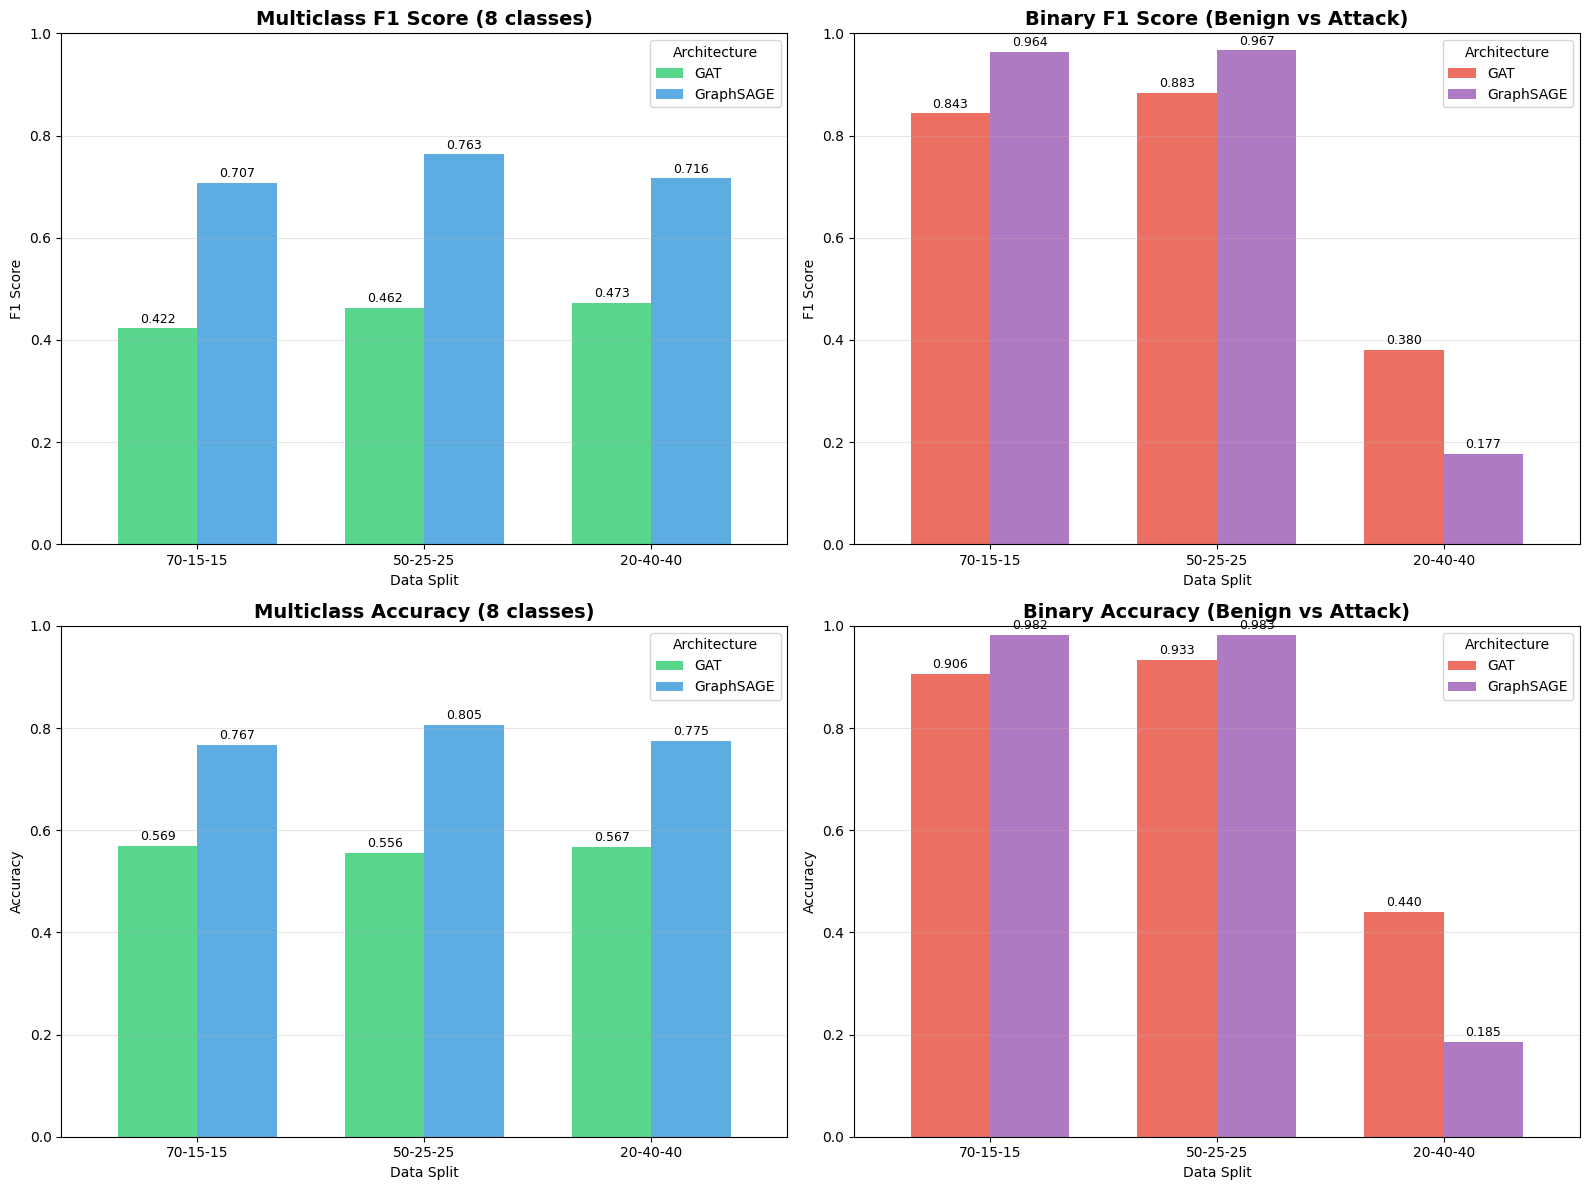


✓ Saved visualization to: models/gnn_12_model_comparison.png


In [10]:
# ============================================================================
# VISUALIZATION
# ============================================================================

import matplotlib.pyplot as plt

print("="*80)
print("VISUALIZATION - 12 MODEL COMPARISON")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

split_order = ['70-15-15', '50-25-25', '20-40-40']

# Plot 1: Multiclass F1 comparison
ax1 = axes[0, 0]
if len(df_multiclass) > 0:
    multi_pivot = df_multiclass.pivot(index='split', columns='architecture', values='f1')
    multi_pivot = multi_pivot.reindex(split_order)
    multi_pivot.plot(kind='bar', ax=ax1, color=['#2ecc71', '#3498db'], alpha=0.8, width=0.7)
    ax1.set_title('Multiclass F1 Score (8 classes)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Data Split')
    ax1.set_ylabel('F1 Score')
    ax1.set_ylim(0, 1)
    ax1.legend(title='Architecture', loc='upper right')
    ax1.set_xticklabels(split_order, rotation=0)
    ax1.grid(True, alpha=0.3, axis='y')
    for container in ax1.containers:
        ax1.bar_label(container, fmt='%.3f', fontsize=9, padding=2)

# Plot 2: Binary F1 comparison
ax2 = axes[0, 1]
if len(df_binary) > 0:
    bin_pivot = df_binary.pivot(index='split', columns='architecture', values='f1')
    bin_pivot = bin_pivot.reindex(split_order)
    bin_pivot.plot(kind='bar', ax=ax2, color=['#e74c3c', '#9b59b6'], alpha=0.8, width=0.7)
    ax2.set_title('Binary F1 Score (Benign vs Attack)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Data Split')
    ax2.set_ylabel('F1 Score')
    ax2.set_ylim(0, 1)
    ax2.legend(title='Architecture', loc='upper right')
    ax2.set_xticklabels(split_order, rotation=0)
    ax2.grid(True, alpha=0.3, axis='y')
    for container in ax2.containers:
        ax2.bar_label(container, fmt='%.3f', fontsize=9, padding=2)

# Plot 3: Multiclass Accuracy comparison
ax3 = axes[1, 0]
if len(df_multiclass) > 0:
    multi_acc = df_multiclass.pivot(index='split', columns='architecture', values='accuracy')
    multi_acc = multi_acc.reindex(split_order)
    multi_acc.plot(kind='bar', ax=ax3, color=['#2ecc71', '#3498db'], alpha=0.8, width=0.7)
    ax3.set_title('Multiclass Accuracy (8 classes)', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Data Split')
    ax3.set_ylabel('Accuracy')
    ax3.set_ylim(0, 1)
    ax3.legend(title='Architecture', loc='upper right')
    ax3.set_xticklabels(split_order, rotation=0)
    ax3.grid(True, alpha=0.3, axis='y')
    for container in ax3.containers:
        ax3.bar_label(container, fmt='%.3f', fontsize=9, padding=2)

# Plot 4: Binary Accuracy comparison
ax4 = axes[1, 1]
if len(df_binary) > 0:
    bin_acc = df_binary.pivot(index='split', columns='architecture', values='accuracy')
    bin_acc = bin_acc.reindex(split_order)
    bin_acc.plot(kind='bar', ax=ax4, color=['#e74c3c', '#9b59b6'], alpha=0.8, width=0.7)
    ax4.set_title('Binary Accuracy (Benign vs Attack)', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Data Split')
    ax4.set_ylabel('Accuracy')
    ax4.set_ylim(0, 1)
    ax4.legend(title='Architecture', loc='upper right')
    ax4.set_xticklabels(split_order, rotation=0)
    ax4.grid(True, alpha=0.3, axis='y')
    for container in ax4.containers:
        ax4.bar_label(container, fmt='%.3f', fontsize=9, padding=2)

plt.tight_layout()
plt.savefig('models/gnn_12_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved visualization to: models/gnn_12_model_comparison.png")

## Section 6: Training Summary

Summary of all 12 trained models with final metrics.

In [11]:
# ============================================================================
# FINAL TRAINING SUMMARY
# ============================================================================

print("="*80)
print("FINAL TRAINING SUMMARY - ALL 12 MODELS")
print("="*80)

# Combined results
all_models_df = pd.concat([df_multiclass, df_binary], ignore_index=True)

print("\n📊 All Models Ranked by F1 Score:")
print("-"*80)
ranked = all_models_df.sort_values('f1', ascending=False)
print(ranked.to_string(index=False))

# Statistics
print("\n" + "="*80)
print("STATISTICS")
print("="*80)

print("\n📈 Multiclass Models:")
print(f"  Average Accuracy: {df_multiclass['accuracy'].mean():.4f}")
print(f"  Average F1 Score: {df_multiclass['f1'].mean():.4f}")
print(f"  Best F1: {df_multiclass['f1'].max():.4f}")

print("\n📈 Binary Models:")
print(f"  Average Accuracy: {df_binary['accuracy'].mean():.4f}")
print(f"  Average F1 Score: {df_binary['f1'].mean():.4f}")
print(f"  Best F1: {df_binary['f1'].max():.4f}")

# Architecture comparison
print("\n📊 Architecture Comparison (Average F1):")
for arch in ['GAT', 'GraphSAGE']:
    multi_f1 = df_multiclass[df_multiclass['architecture'] == arch]['f1'].mean()
    bin_f1 = df_binary[df_binary['architecture'] == arch]['f1'].mean()
    print(f"  {arch}: Multiclass={multi_f1:.4f}, Binary={bin_f1:.4f}")

# Split comparison
print("\n📊 Split Comparison (Average F1):")
for split in ['70-15-15', '50-25-25', '20-40-40']:
    multi_f1 = df_multiclass[df_multiclass['split'] == split]['f1'].mean()
    bin_f1 = df_binary[df_binary['split'] == split]['f1'].mean()
    print(f"  {split}: Multiclass={multi_f1:.4f}, Binary={bin_f1:.4f}")

print("\n" + "="*80)
print("TRAINED MODELS LOCATION")
print("="*80)
print(f"\n📁 Multiclass models: {MODEL_DIR_MULTICLASS}/")
print(f"📁 Binary models: {MODEL_DIR_BINARY}/")
print(f"📁 Comparison CSV: models/all_12_models_comparison.csv")

FINAL TRAINING SUMMARY - ALL 12 MODELS

📊 All Models Ranked by F1 Score:
--------------------------------------------------------------------------------
architecture    split       task  accuracy  precision   recall       f1
   GraphSAGE 50-25-25     binary  0.982830   0.956680 0.977140 0.966563
   GraphSAGE 70-15-15     binary  0.981554   0.955552 0.972862 0.963957
         GAT 50-25-25     binary  0.933111   0.846422 0.938050 0.882892
         GAT 70-15-15     binary  0.906321   0.804103 0.913839 0.843323
   GraphSAGE 50-25-25 multiclass  0.805393   0.790856 0.768690 0.763138
   GraphSAGE 20-40-40 multiclass  0.775416   0.734624 0.731137 0.716097
   GraphSAGE 70-15-15 multiclass  0.767431   0.761161 0.693007 0.706730
         GAT 20-40-40 multiclass  0.566759   0.537961 0.480861 0.472799
         GAT 50-25-25 multiclass  0.555696   0.522219 0.500947 0.462108
         GAT 70-15-15 multiclass  0.568527   0.413784 0.481588 0.422365
         GAT 20-40-40     binary  0.439685   0.468968 

## Summary

### Trained Models (12 total):

**Multiclass (8 classes)** - `models/multiclass/`
| Architecture | Split | Model File |
|--------------|-------|------------|
| GAT | 70-15-15 | `gnn_gat_70_15_15.pt` |
| GAT | 50-25-25 | `gnn_gat_50_25_25.pt` |
| GAT | 20-40-40 | `gnn_gat_20_40_40.pt` |
| GraphSAGE | 70-15-15 | `gnn_graphsage_70_15_15.pt` |
| GraphSAGE | 50-25-25 | `gnn_graphsage_50_25_25.pt` |
| GraphSAGE | 20-40-40 | `gnn_graphsage_20_40_40.pt` |

**Binary (Benign vs Attack)** - `models/binary/`
| Architecture | Split | Model File |
|--------------|-------|------------|
| GAT | 70-15-15 | `gnn_gat_70_15_15.pt` |
| GAT | 50-25-25 | `gnn_gat_50_25_25.pt` |
| GAT | 20-40-40 | `gnn_gat_20_40_40.pt` |
| GraphSAGE | 70-15-15 | `gnn_graphsage_70_15_15.pt` |
| GraphSAGE | 50-25-25 | `gnn_graphsage_50_25_25.pt` |
| GraphSAGE | 20-40-40 | `gnn_graphsage_20_40_40.pt` |

### Improved Hyperparameters:
- **Hidden dimension**: 128 (increased from 64)
- **GAT heads**: 4 (increased from 2)
- **GraphSAGE layers**: 3 (deeper aggregation)
- **Learning rate**: 5e-4 (more stable)
- **Weight decay**: 1e-4 (stronger regularization)
- **Patience**: 30 epochs (longer early stopping)

### Usage:
```python
import torch
from gnn_utils import GATModel, GraphSAGEModel, LABEL_MAP

# Load multiclass model
checkpoint = torch.load('models/multiclass/gnn_gat_70_15_15.pt')
model = GATModel(num_features=20, hidden_dim=128, num_classes=8, heads=4)
model.load_state_dict(checkpoint['model_state_dict'])

# Load binary model
checkpoint = torch.load('models/binary/gnn_graphsage_70_15_15.pt')
model = GraphSAGEModel(num_features=20, hidden_dim=128, num_classes=2, num_layers=3)
model.load_state_dict(checkpoint['model_state_dict'])
```

---

# 52-Feature Training Pipeline

Now we repeat the same 12-model training process using the **52-feature dataset** for comparison with the 20-feature results above.

In [12]:
# ============================================================================
# 52-FEATURE TRAINING - LOAD AND PREPROCESS DATA
# ============================================================================

print("="*80)
print("52-FEATURE TRAINING PIPELINE")
print("="*80)

# Path to 52-feature training data
CSV_PATH_52 = 'checkpoints/ctgan/balanced_52.csv'

# Create separate directories for 52-feature models
MODEL_DIR_MULTICLASS_52 = 'models/multiclass_52'
MODEL_DIR_BINARY_52 = 'models/binary_52'
CHECKPOINT_DIR_52 = 'checkpoints/gnn_training_52'

os.makedirs(MODEL_DIR_MULTICLASS_52, exist_ok=True)
os.makedirs(MODEL_DIR_BINARY_52, exist_ok=True)
os.makedirs(CHECKPOINT_DIR_52, exist_ok=True)

print(f"\n✓ Created 52-feature output directories:")
print(f"  - {MODEL_DIR_MULTICLASS_52}/")
print(f"  - {MODEL_DIR_BINARY_52}/")
print(f"  - {CHECKPOINT_DIR_52}/")

# Helper functions for 52-feature checkpoints
def save_checkpoint_52(name, data):
    """Save checkpoint data to disk."""
    path = os.path.join(CHECKPOINT_DIR_52, f"{name}.pkl")
    with open(path, 'wb') as f:
        pickle.dump(data, f)
    print(f"  ✓ Checkpoint saved: {path}")

def load_checkpoint_52(name):
    """Load checkpoint data from disk if exists."""
    path = os.path.join(CHECKPOINT_DIR_52, f"{name}.pkl")
    if os.path.exists(path):
        with open(path, 'rb') as f:
            data = pickle.load(f)
        print(f"  ✓ Checkpoint loaded: {path}")
        return data
    return None

def checkpoint_exists_52(name):
    """Check if a checkpoint exists."""
    path = os.path.join(CHECKPOINT_DIR_52, f"{name}.pkl")
    return os.path.exists(path)

# Check for existing checkpoint
if checkpoint_exists_52('multiclass_data'):
    print("\n📂 Loading 52-feature data from checkpoint...")
    ckpt_52 = load_checkpoint_52('multiclass_data')
    X_scaled_52 = ckpt_52['X_scaled']
    y_encoded_52 = ckpt_52['y_encoded']
    protocols_52 = ckpt_52['protocols']
    feature_names_52 = ckpt_52['feature_names']
    label_map_52 = ckpt_52['label_map']
    n_samples_52 = X_scaled_52.shape[0]
    num_features_52 = X_scaled_52.shape[1]
    num_classes_52 = len(set(y_encoded_52))
else:
    print("\n🔄 Processing 52-feature data from scratch...")
    # Load and preprocess (multiclass labels)
    X_scaled_52, y_encoded_52, scaler_52, protocols_52, feature_names_52, label_map_52 = load_and_preprocess_gnn_data(
        CSV_PATH_52,
        scaler_path='scalers/gnn_scaler_multiclass_52.pkl',
        fit_scaler=True,
        binary_labels=False
    )
    
    # Store for later use
    n_samples_52 = X_scaled_52.shape[0]
    num_features_52 = X_scaled_52.shape[1]
    num_classes_52 = len(set(y_encoded_52))
    
    # Save checkpoint
    save_checkpoint_52('multiclass_data', {
        'X_scaled': X_scaled_52,
        'y_encoded': y_encoded_52,
        'protocols': protocols_52,
        'feature_names': feature_names_52,
        'label_map': label_map_52
    })

print(f"\n✓ 52-Feature Data loaded successfully:")
print(f"  Samples: {n_samples_52:,}")
print(f"  Features: {num_features_52}")
print(f"  Classes: {num_classes_52}")
print(f"  Class distribution: {dict(Counter(y_encoded_52))}")

52-FEATURE TRAINING PIPELINE

✓ Created 52-feature output directories:
  - models/multiclass_52/
  - models/binary_52/
  - checkpoints/gnn_training_52/

🔄 Processing 52-feature data from scratch...
Loading and preprocessing data for GNN...
  Loaded checkpoints/ctgan/balanced_52.csv: (464770, 52)
  Combined shape: (464770, 52)
  Loaded checkpoints/ctgan/balanced_52.csv: (464770, 52)
  Combined shape: (464770, 52)

  Features: 51
  Label mapping: {0: 'BFA', 1: 'BOTNET', 2: 'DDoS', 3: 'DoS', 4: 'Normal', 5: 'Probe', 6: 'U2R', 7: 'Web-Attack'}
  Class distribution: {np.int64(0): 36798, np.int64(1): 36798, np.int64(2): 121942, np.int64(3): 53616, np.int64(4): 68424, np.int64(5): 73596, np.int64(6): 36798, np.int64(7): 36798}

  Fitting RobustScaler...

  Features: 51
  Label mapping: {0: 'BFA', 1: 'BOTNET', 2: 'DDoS', 3: 'DoS', 4: 'Normal', 5: 'Probe', 6: 'U2R', 7: 'Web-Attack'}
  Class distribution: {np.int64(0): 36798, np.int64(1): 36798, np.int64(2): 121942, np.int64(3): 53616, np.int64(

In [13]:
# Build protocol-aware k-NN graph for 52-feature data
print("="*80)
print("BUILDING PROTOCOL-AWARE K-NN GRAPH (52 features)")
print("="*80)

# Check for existing checkpoint
if checkpoint_exists_52('multiclass_graph'):
    print("\n📂 Loading 52-feature graph from checkpoint...")
    ckpt_52 = load_checkpoint_52('multiclass_graph')
    edge_index_52 = ckpt_52['edge_index']
else:
    print("\n🔄 Building 52-feature graph from scratch...")
    # Build graph with protocol awareness
    edge_index_52 = build_protocol_aware_knn_graph(X_scaled_52, protocols_52, k=5)
    
    # Save checkpoint
    save_checkpoint_52('multiclass_graph', {
        'edge_index': edge_index_52
    })

print(f"\n✓ 52-Feature Graph construction complete:")
print(f"  Nodes: {n_samples_52:,}")
print(f"  Edges: {edge_index_52.shape[1]:,}")
print(f"  Average degree: {edge_index_52.shape[1] / n_samples_52:.2f}")

BUILDING PROTOCOL-AWARE K-NN GRAPH (52 features)

🔄 Building 52-feature graph from scratch...

Building Protocol-Aware k-NN graph (k=5)...
  Protocol groups found: {np.str_('TCP'): 302969, np.str_('UDP'): 39952, np.str_('Other'): 121849}
  Other: 121849 nodes, 609245 edges
  Other: 121849 nodes, 609245 edges
  TCP: 302969 nodes, 1514845 edges
  TCP: 302969 nodes, 1514845 edges
  UDP: 39952 nodes, 199760 edges
  ✓ Total graph: 464770 nodes, 2323850 edges
  Average degree: 5.00
  ✓ Checkpoint saved: checkpoints/gnn_training_52/multiclass_graph.pkl

✓ 52-Feature Graph construction complete:
  Nodes: 464,770
  Edges: 2,323,850
  Average degree: 5.00
  UDP: 39952 nodes, 199760 edges
  ✓ Total graph: 464770 nodes, 2323850 edges
  Average degree: 5.00
  ✓ Checkpoint saved: checkpoints/gnn_training_52/multiclass_graph.pkl

✓ 52-Feature Graph construction complete:
  Nodes: 464,770
  Edges: 2,323,850
  Average degree: 5.00


In [14]:
# ============================================================================
# 52-FEATURE: MULTICLASS MODELS (6 models: 2 architectures × 3 splits)
# ============================================================================

print("\n" + "="*80)
print("52-FEATURE: TRAINING MULTICLASS MODELS (8 classes)")
print("="*80)

# Clear GPU memory
clear_gpu_memory()

# Store results for 52-feature models
all_results_52 = {
    'multiclass': [],
    'binary': []
}

for arch in ARCHITECTURES:
    for split_name, (train_ratio, val_ratio) in SPLITS.items():
        model_name = f"gnn_{arch.lower()}_{split_name.replace('-', '_')}"
        model_path = os.path.join(MODEL_DIR_MULTICLASS_52, f"{model_name}.pt")
        
        print(f"\n{'='*60}")
        print(f"Training: {arch} - {split_name} (52-Feature Multiclass)")
        print(f"{'='*60}")
        
        # Check for existing checkpoint
        ckpt_name = f"results_multiclass_{arch.lower()}_{split_name.replace('-', '_')}"
        
        if os.path.exists(model_path) and checkpoint_exists_52(ckpt_name):
            print(f"📂 Loading from checkpoint: {model_path}")
            ckpt_52 = load_checkpoint_52(ckpt_name)
            results = ckpt_52['results']
            all_results_52['multiclass'].append(results)
            print(f"  Accuracy: {results['accuracy']:.4f}, F1: {results['f1']:.4f}")
            continue
        
        # Clear GPU before each model
        clear_gpu_memory()
        print(f"🔄 Training on GPU (mem free: {torch.cuda.memory_reserved(0)/1e9:.2f}GB reserved)")
        
        # Create masks
        train_mask, val_mask, test_mask = create_train_val_test_masks(
            n_samples_52, y_encoded_52, train_ratio=train_ratio, val_ratio=val_ratio
        )
        
        # Create data object and move to GPU
        data = create_pyg_data(X_scaled_52, y_encoded_52, edge_index_52, train_mask, val_mask, test_mask)
        data = data.to(training_device)
        
        # Calculate class weights
        y_train = y_encoded_52[train_mask]
        weights = calculate_class_weights(y_train)
        
        # Create model based on architecture
        hp = HYPERPARAMS[arch]
        if arch == 'GAT':
            model = GATModel(
                num_features=num_features_52,
                hidden_dim=hp['hidden_dim'],
                num_classes=num_classes_52,
                heads=hp['heads'],
                dropout=hp['dropout'],
                device=training_device
            )
        else:  # GraphSAGE
            model = GraphSAGEModel(
                num_features=num_features_52,
                hidden_dim=hp['hidden_dim'],
                num_classes=num_classes_52,
                dropout=hp['dropout'],
                num_layers=hp['num_layers'],
                device=training_device
            )
        
        # Setup training
        optimizer = optim.Adam(
            model.parameters(), 
            lr=TRAINING_CONFIG['lr'], 
            weight_decay=TRAINING_CONFIG['weight_decay']
        )
        criterion = nn.CrossEntropyLoss(weight=weights.to(training_device))
        
        # Train with early stopping
        best_model, history = train_gnn_with_early_stopping(
            model, data, optimizer, criterion, training_device,
            num_epochs=TRAINING_CONFIG['num_epochs'],
            patience=TRAINING_CONFIG['patience'],
            verbose=True
        )
        
        # Evaluate on test set
        test_metrics = evaluate_gnn(best_model, data, data.test_mask, training_device)
        
        # Move model to CPU for saving
        best_model_cpu = best_model.to('cpu')
        
        # Save model
        save_gnn_model(
            best_model_cpu, model_path,
            metadata={
                'architecture': arch,
                'split': split_name,
                'task': 'multiclass',
                'features': 52,
                'test_f1': test_metrics['f1'],
                'test_accuracy': test_metrics['accuracy'],
                'num_features': num_features_52,
                'num_classes': num_classes_52,
                **hp
            },
            label_map=label_map_52
        )
        
        # Print metrics
        print(f"\n  Test Accuracy: {test_metrics['accuracy']:.4f}")
        print(f"  Test F1: {test_metrics['f1']:.4f}")
        print(f"  Test Precision: {test_metrics['precision']:.4f}")
        print(f"  Test Recall: {test_metrics['recall']:.4f}")
        
        # Store results
        results = {
            'architecture': arch,
            'split': split_name,
            'task': 'multiclass',
            'features': 52,
            'accuracy': test_metrics['accuracy'],
            'precision': test_metrics['precision'],
            'recall': test_metrics['recall'],
            'f1': test_metrics['f1']
        }
        all_results_52['multiclass'].append(results)
        
        # Save checkpoint
        save_checkpoint_52(ckpt_name, {
            'results': results,
            'test_metrics': {k: v for k, v in test_metrics.items() 
                           if k not in ['predictions', 'true_labels']}
        })
        
        print(f"✓ Saved: {model_path}")
        
        # AGGRESSIVE MEMORY CLEANUP
        del model, best_model, best_model_cpu, data, optimizer, criterion, weights
        del train_mask, val_mask, test_mask, test_metrics
        clear_gpu_memory()
        print(f"  Memory cleaned (GPU reserved: {torch.cuda.memory_reserved(0)/1e9:.2f}GB)")

print("\n" + "="*80)
print("52-FEATURE MULTICLASS TRAINING COMPLETE")
print("="*80)

# Show multiclass summary
df_multi_52 = pd.DataFrame(all_results_52['multiclass'])
print("\n52-Feature Multiclass Results Summary:")
print(df_multi_52.to_string(index=False))


52-FEATURE: TRAINING MULTICLASS MODELS (8 classes)

Training: GAT - 70-15-15 (52-Feature Multiclass)
🔄 Training on GPU (mem free: 0.02GB reserved)
  Split: Train=325338, Val=69715, Test=69717

Class weights (inverse frequency):
  Class 0: 1.5788
  Class 1: 1.5788
  Class 2: 0.4764
  Class 3: 1.0836
  Class 4: 0.8491
  Class 5: 0.7894
  Class 6: 1.5788
  Class 7: 1.5788

Training GNN (max 200 epochs, patience 25)...
  Epoch   0: Train Loss=8136388.0000, Val Loss=5386112.0000, Val Acc=0.2630, Val F1=0.1451
  Epoch   1: Train Loss=7307453.0000, Val Loss=4687208.0000, Val Acc=0.2744, Val F1=0.1490
  Epoch   2: Train Loss=6717686.5000, Val Loss=4014529.5000, Val Acc=0.3287, Val F1=0.2342
  Epoch   0: Train Loss=8136388.0000, Val Loss=5386112.0000, Val Acc=0.2630, Val F1=0.1451
  Epoch   1: Train Loss=7307453.0000, Val Loss=4687208.0000, Val Acc=0.2744, Val F1=0.1490
  Epoch   2: Train Loss=6717686.5000, Val Loss=4014529.5000, Val Acc=0.3287, Val F1=0.2342
  Epoch   3: Train Loss=6352711.00

In [15]:
# ============================================================================
# 52-FEATURE: LOAD BINARY DATA
# ============================================================================

print("="*80)
print("LOADING 52-FEATURE BINARY DATA")
print("="*80)

BINARY_DATA_CHECKPOINT_52 = os.path.join(CHECKPOINT_DIR_52, 'binary_preprocessed_data.npz')
BINARY_EDGE_CHECKPOINT_52 = os.path.join(CHECKPOINT_DIR_52, 'binary_edge_index.npz')
BINARY_SCALER_PATH_52 = 'scalers/gnn_scaler_binary_52.pkl'

# Check for existing checkpoints
if os.path.exists(BINARY_DATA_CHECKPOINT_52) and os.path.exists(BINARY_EDGE_CHECKPOINT_52):
    print("\n📂 Loading 52-feature binary data from checkpoint...")
    
    # Load preprocessed data
    binary_data_52 = np.load(BINARY_DATA_CHECKPOINT_52)
    X_binary_52 = binary_data_52['X_scaled']
    y_binary_52 = binary_data_52['y_encoded']
    protocols_binary_52 = binary_data_52['protocols']
    feature_names_binary_52 = binary_data_52['feature_names'].tolist()
    
    # Load binary label map
    binary_label_map_52 = BINARY_LABEL_MAP
    
    # Load scaler
    scaler_binary_52 = joblib.load(BINARY_SCALER_PATH_52)
    
    # Load edge_index
    edge_sparse_52 = scipy.sparse.load_npz(BINARY_EDGE_CHECKPOINT_52)
    edge_index_binary_52 = torch.tensor(np.vstack([edge_sparse_52.row, edge_sparse_52.col]), dtype=torch.long)
    
    print(f"\n✓ 52-Feature Binary data loaded from checkpoint:")
    print(f"  Samples: {X_binary_52.shape[0]:,}")
    print(f"  Features: {X_binary_52.shape[1]}")
    print(f"  Binary classes: {binary_label_map_52}")
    print(f"  Class distribution: {dict(Counter(y_binary_52))}")
    print(f"  Graph edges: {edge_index_binary_52.shape[1]:,}")
    
else:
    print("\n🔄 Processing 52-feature binary data from scratch...")
    
    # Reload data with binary label encoding
    X_binary_52, y_binary_52, scaler_binary_52, protocols_binary_52, feature_names_binary_52, binary_label_map_52 = load_and_preprocess_gnn_data(
        CSV_PATH_52,
        scaler_path=BINARY_SCALER_PATH_52,
        fit_scaler=True,
        binary_labels=True
    )

    print(f"\n✓ 52-Feature Binary data loaded:")
    print(f"  Samples: {X_binary_52.shape[0]:,}")
    print(f"  Features: {X_binary_52.shape[1]}")
    print(f"  Binary classes: {binary_label_map_52}")
    print(f"  Class distribution: {dict(Counter(y_binary_52))}")

    # Build protocol-aware graph for binary data
    print("\nBuilding protocol-aware graph for 52-feature binary data...")
    edge_index_binary_52 = build_protocol_aware_knn_graph(X_binary_52, protocols_binary_52, k=5)
    
    # Save checkpoints
    np.savez(BINARY_DATA_CHECKPOINT_52,
             X_scaled=X_binary_52,
             y_encoded=y_binary_52,
             protocols=protocols_binary_52,
             feature_names=np.array(feature_names_binary_52))
    
    edge_sparse_52 = scipy.sparse.coo_matrix(
        (np.ones(edge_index_binary_52.shape[1]), (edge_index_binary_52[0].numpy(), edge_index_binary_52[1].numpy())),
        shape=(X_binary_52.shape[0], X_binary_52.shape[0])
    )
    scipy.sparse.save_npz(BINARY_EDGE_CHECKPOINT_52, edge_sparse_52)
    
    print(f"\n✓ 52-Feature Binary data checkpoints saved to: {CHECKPOINT_DIR_52}")

LOADING 52-FEATURE BINARY DATA

🔄 Processing 52-feature binary data from scratch...
Loading and preprocessing data for GNN...
  Loaded checkpoints/ctgan/balanced_52.csv: (464770, 52)
  Combined shape: (464770, 52)
  Loaded checkpoints/ctgan/balanced_52.csv: (464770, 52)
  Combined shape: (464770, 52)

  Features: 51
  Label mapping: {0: 'Benign', 1: 'Attack'}
  Class distribution: {np.int64(1): 396346, np.int64(0): 68424}

  Fitting RobustScaler...

  Features: 51
  Label mapping: {0: 'Benign', 1: 'Attack'}
  Class distribution: {np.int64(1): 396346, np.int64(0): 68424}

  Fitting RobustScaler...
  ✓ Scaler saved to: scalers/gnn_scaler_binary_52.pkl

✓ 52-Feature Binary data loaded:
  Samples: 464,770
  Features: 51
  Binary classes: {0: 'Benign', 1: 'Attack'}
  Class distribution: {np.int64(1): 396346, np.int64(0): 68424}

Building protocol-aware graph for 52-feature binary data...

Building Protocol-Aware k-NN graph (k=5)...
  Protocol groups found: {np.str_('TCP'): 302969, np.str_('

In [16]:
# ============================================================================
# 52-FEATURE: BINARY MODELS (6 models: 2 architectures × 3 splits)
# ============================================================================

print("\n" + "="*80)
print("52-FEATURE: TRAINING BINARY MODELS (Benign vs Attack)")
print("="*80)

# Clear memory before starting binary training
clear_gpu_memory()

for arch in ARCHITECTURES:
    for split_name, (train_ratio, val_ratio) in SPLITS.items():
        model_name = f"gnn_{arch.lower()}_{split_name.replace('-', '_')}"
        model_path = os.path.join(MODEL_DIR_BINARY_52, f"{model_name}.pt")
        
        print(f"\n{'='*60}")
        print(f"Training: {arch} - {split_name} (52-Feature Binary)")
        print(f"{'='*60}")
        
        # Check for existing checkpoint
        ckpt_name = f"results_binary_{arch.lower()}_{split_name.replace('-', '_')}"
        
        if os.path.exists(model_path) and checkpoint_exists_52(ckpt_name):
            print(f"📂 Loading from checkpoint: {model_path}")
            ckpt_52 = load_checkpoint_52(ckpt_name)
            results = ckpt_52['results']
            all_results_52['binary'].append(results)
            print(f"  Accuracy: {results['accuracy']:.4f}, F1: {results['f1']:.4f}")
            continue
        
        # Clear GPU before each model
        clear_gpu_memory()
        print(f"🔄 Training on GPU (mem free: {torch.cuda.memory_reserved(0)/1e9:.2f}GB reserved)")
        
        # Create masks for binary data
        n_binary_52 = X_binary_52.shape[0]
        train_mask, val_mask, test_mask = create_train_val_test_masks(
            n_binary_52, y_binary_52, train_ratio=train_ratio, val_ratio=val_ratio
        )
        
        # Create data object and move to GPU
        data = create_pyg_data(X_binary_52, y_binary_52, edge_index_binary_52, 
                               train_mask, val_mask, test_mask)
        data = data.to(training_device)
        
        # Calculate class weights
        y_train = y_binary_52[train_mask]
        weights = calculate_class_weights(y_train)
        
        # Create model based on architecture
        hp = HYPERPARAMS[arch]
        if arch == 'GAT':
            model = GATModel(
                num_features=X_binary_52.shape[1],
                hidden_dim=hp['hidden_dim'],
                num_classes=2,
                heads=hp['heads'],
                dropout=hp['dropout'],
                device=training_device
            )
        else:  # GraphSAGE
            model = GraphSAGEModel(
                num_features=X_binary_52.shape[1],
                hidden_dim=hp['hidden_dim'],
                num_classes=2,
                dropout=hp['dropout'],
                num_layers=hp['num_layers'],
                device=training_device
            )
        
        # Setup training
        optimizer = optim.Adam(
            model.parameters(),
            lr=TRAINING_CONFIG['lr'],
            weight_decay=TRAINING_CONFIG['weight_decay']
        )
        criterion = nn.CrossEntropyLoss(weight=weights.to(training_device))
        
        # Train with early stopping
        best_model, history = train_gnn_with_early_stopping(
            model, data, optimizer, criterion, training_device,
            num_epochs=TRAINING_CONFIG['num_epochs'],
            patience=TRAINING_CONFIG['patience'],
            verbose=True
        )
        
        # Evaluate on test set
        test_metrics = evaluate_gnn(best_model, data, data.test_mask, training_device)
        
        # Move model to CPU for saving
        best_model_cpu = best_model.to('cpu')
        
        # Save model
        save_gnn_model(
            best_model_cpu, model_path,
            metadata={
                'architecture': arch,
                'split': split_name,
                'task': 'binary',
                'features': 52,
                'test_f1': test_metrics['f1'],
                'test_accuracy': test_metrics['accuracy'],
                'num_features': X_binary_52.shape[1],
                'num_classes': 2,
                **hp
            },
            label_map=binary_label_map_52
        )
        
        # Print metrics
        print(f"\n  Test Accuracy: {test_metrics['accuracy']:.4f}")
        print(f"  Test F1: {test_metrics['f1']:.4f}")
        print(f"  Test Precision: {test_metrics['precision']:.4f}")
        print(f"  Test Recall: {test_metrics['recall']:.4f}")
        
        # Store results
        results = {
            'architecture': arch,
            'split': split_name,
            'task': 'binary',
            'features': 52,
            'accuracy': test_metrics['accuracy'],
            'precision': test_metrics['precision'],
            'recall': test_metrics['recall'],
            'f1': test_metrics['f1']
        }
        all_results_52['binary'].append(results)
        
        # Save checkpoint
        save_checkpoint_52(ckpt_name, {
            'results': results,
            'test_metrics': {k: v for k, v in test_metrics.items() 
                           if k not in ['predictions', 'true_labels']}
        })
        
        print(f"✓ Saved: {model_path}")
        
        # AGGRESSIVE MEMORY CLEANUP
        del model, best_model, best_model_cpu, data, optimizer, criterion, weights
        del train_mask, val_mask, test_mask, test_metrics
        clear_gpu_memory()
        print(f"  Memory cleaned (GPU reserved: {torch.cuda.memory_reserved(0)/1e9:.2f}GB)")

print("\n" + "="*80)
print("52-FEATURE BINARY TRAINING COMPLETE")
print("="*80)

# Show binary summary
df_binary_52 = pd.DataFrame(all_results_52['binary'])
print("\n52-Feature Binary Results Summary:")
print(df_binary_52.to_string(index=False))


52-FEATURE: TRAINING BINARY MODELS (Benign vs Attack)

Training: GAT - 70-15-15 (52-Feature Binary)
🔄 Training on GPU (mem free: 0.02GB reserved)
  Split: Train=325338, Val=69715, Test=69717

Class weights (inverse frequency):
  Class 0: 3.3962
  Class 1: 0.5863

Training GNN (max 200 epochs, patience 25)...
  Epoch   0: Train Loss=7126676.0000, Val Loss=793422.6250, Val Acc=0.6837, Val F1=0.6097
  Epoch   0: Train Loss=7126676.0000, Val Loss=793422.6250, Val Acc=0.6837, Val F1=0.6097
  Epoch  10: Train Loss=1982833.5000, Val Loss=3815134.7500, Val Acc=0.6726, Val F1=0.6053
  Epoch  10: Train Loss=1982833.5000, Val Loss=3815134.7500, Val Acc=0.6726, Val F1=0.6053
  Epoch  20: Train Loss=1581565.1250, Val Loss=4655381.0000, Val Acc=0.6774, Val F1=0.6084
  Epoch  20: Train Loss=1581565.1250, Val Loss=4655381.0000, Val Acc=0.6774, Val F1=0.6084

  ✓ Early stopping at epoch 25 (no improvement for 25 epochs)
  ✓ Training complete. Best val loss: 793422.6250
  ✓ Model saved to: models/binar

In [17]:
# ============================================================================
# 52-FEATURE COMPARISON TABLES
# ============================================================================

print("="*80)
print("52-FEATURE MODEL COMPARISON TABLES - ALL 12 MODELS")
print("="*80)

# Create DataFrames for 52-feature models
df_multiclass_52 = pd.DataFrame(all_results_52['multiclass'])
df_binary_52 = pd.DataFrame(all_results_52['binary'])

# ============================================================================
# TABLE 1: 52-FEATURE MULTICLASS COMPARISON
# ============================================================================
print("\n" + "="*80)
print("TABLE 1: 52-FEATURE MULTICLASS MODEL COMPARISON (8 classes)")
print("="*80)

split_order = ['70-15-15', '50-25-25', '20-40-40']

print("\n" + "-"*100)
print(f"{'Split':<12} | {'GAT Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} | {'SAGE Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
print("-"*100)

for split in split_order:
    gat_row = df_multiclass_52[(df_multiclass_52['split'] == split) & (df_multiclass_52['architecture'] == 'GAT')]
    sage_row = df_multiclass_52[(df_multiclass_52['split'] == split) & (df_multiclass_52['architecture'] == 'GraphSAGE')]
    
    if len(gat_row) > 0 and len(sage_row) > 0:
        gat = gat_row.iloc[0]
        sage = sage_row.iloc[0]
        print(f"{split:<12} | {gat['accuracy']:>8.4f} {gat['precision']:>8.4f} {gat['recall']:>8.4f} {gat['f1']:>8.4f} | "
              f"{sage['accuracy']:>8.4f} {sage['precision']:>8.4f} {sage['recall']:>8.4f} {sage['f1']:>8.4f}")

print("-"*100)

# Find best multiclass model
if len(df_multiclass_52) > 0:
    best_multi_52 = df_multiclass_52.loc[df_multiclass_52['f1'].idxmax()]
    print(f"\n🏆 Best 52-Feature Multiclass: {best_multi_52['architecture']} {best_multi_52['split']}")
    print(f"   Accuracy: {best_multi_52['accuracy']:.4f}, F1: {best_multi_52['f1']:.4f}")

# ============================================================================
# TABLE 2: 52-FEATURE BINARY COMPARISON
# ============================================================================
print("\n" + "="*80)
print("TABLE 2: 52-FEATURE BINARY MODEL COMPARISON (Benign vs Attack)")
print("="*80)

print("\n" + "-"*100)
print(f"{'Split':<12} | {'GAT Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} | {'SAGE Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
print("-"*100)

for split in split_order:
    gat_row = df_binary_52[(df_binary_52['split'] == split) & (df_binary_52['architecture'] == 'GAT')]
    sage_row = df_binary_52[(df_binary_52['split'] == split) & (df_binary_52['architecture'] == 'GraphSAGE')]
    
    if len(gat_row) > 0 and len(sage_row) > 0:
        gat = gat_row.iloc[0]
        sage = sage_row.iloc[0]
        print(f"{split:<12} | {gat['accuracy']:>8.4f} {gat['precision']:>8.4f} {gat['recall']:>8.4f} {gat['f1']:>8.4f} | "
              f"{sage['accuracy']:>8.4f} {sage['precision']:>8.4f} {sage['recall']:>8.4f} {sage['f1']:>8.4f}")

print("-"*100)

# Find best binary model
if len(df_binary_52) > 0:
    best_bin_52 = df_binary_52.loc[df_binary_52['f1'].idxmax()]
    print(f"\n🏆 Best 52-Feature Binary: {best_bin_52['architecture']} {best_bin_52['split']}")
    print(f"   Accuracy: {best_bin_52['accuracy']:.4f}, F1: {best_bin_52['f1']:.4f}")

# Save to CSV
df_multiclass_52.to_csv(os.path.join(MODEL_DIR_MULTICLASS_52, 'comparison.csv'), index=False)
df_binary_52.to_csv(os.path.join(MODEL_DIR_BINARY_52, 'comparison.csv'), index=False)

# Combined summary for 52-feature
all_models_52 = pd.concat([df_multiclass_52, df_binary_52], ignore_index=True)
all_models_52.to_csv('models/all_12_models_comparison_52.csv', index=False)

print(f"\n✓ Saved 52-feature comparison tables:")
print(f"  - {MODEL_DIR_MULTICLASS_52}/comparison.csv")
print(f"  - {MODEL_DIR_BINARY_52}/comparison.csv")
print(f"  - models/all_12_models_comparison_52.csv")

52-FEATURE MODEL COMPARISON TABLES - ALL 12 MODELS

TABLE 1: 52-FEATURE MULTICLASS MODEL COMPARISON (8 classes)

----------------------------------------------------------------------------------------------------
Split        |  GAT Acc     Prec      Rec       F1 | SAGE Acc     Prec      Rec       F1
----------------------------------------------------------------------------------------------------
70-15-15     |   0.3671   0.3875   0.2848   0.2382 |   0.6251   0.5303   0.5026   0.4759
50-25-25     |   0.2967   0.1447   0.2075   0.1507 |   0.5471   0.4741   0.4629   0.4143
20-40-40     |   0.2530   0.2848   0.3105   0.2383 |   0.5952   0.5445   0.4870   0.4515
----------------------------------------------------------------------------------------------------

🏆 Best 52-Feature Multiclass: GraphSAGE 70-15-15
   Accuracy: 0.6251, F1: 0.4759

TABLE 2: 52-FEATURE BINARY MODEL COMPARISON (Benign vs Attack)

---------------------------------------------------------------------------------

VISUALIZATION - 52-FEATURE 12 MODEL COMPARISON


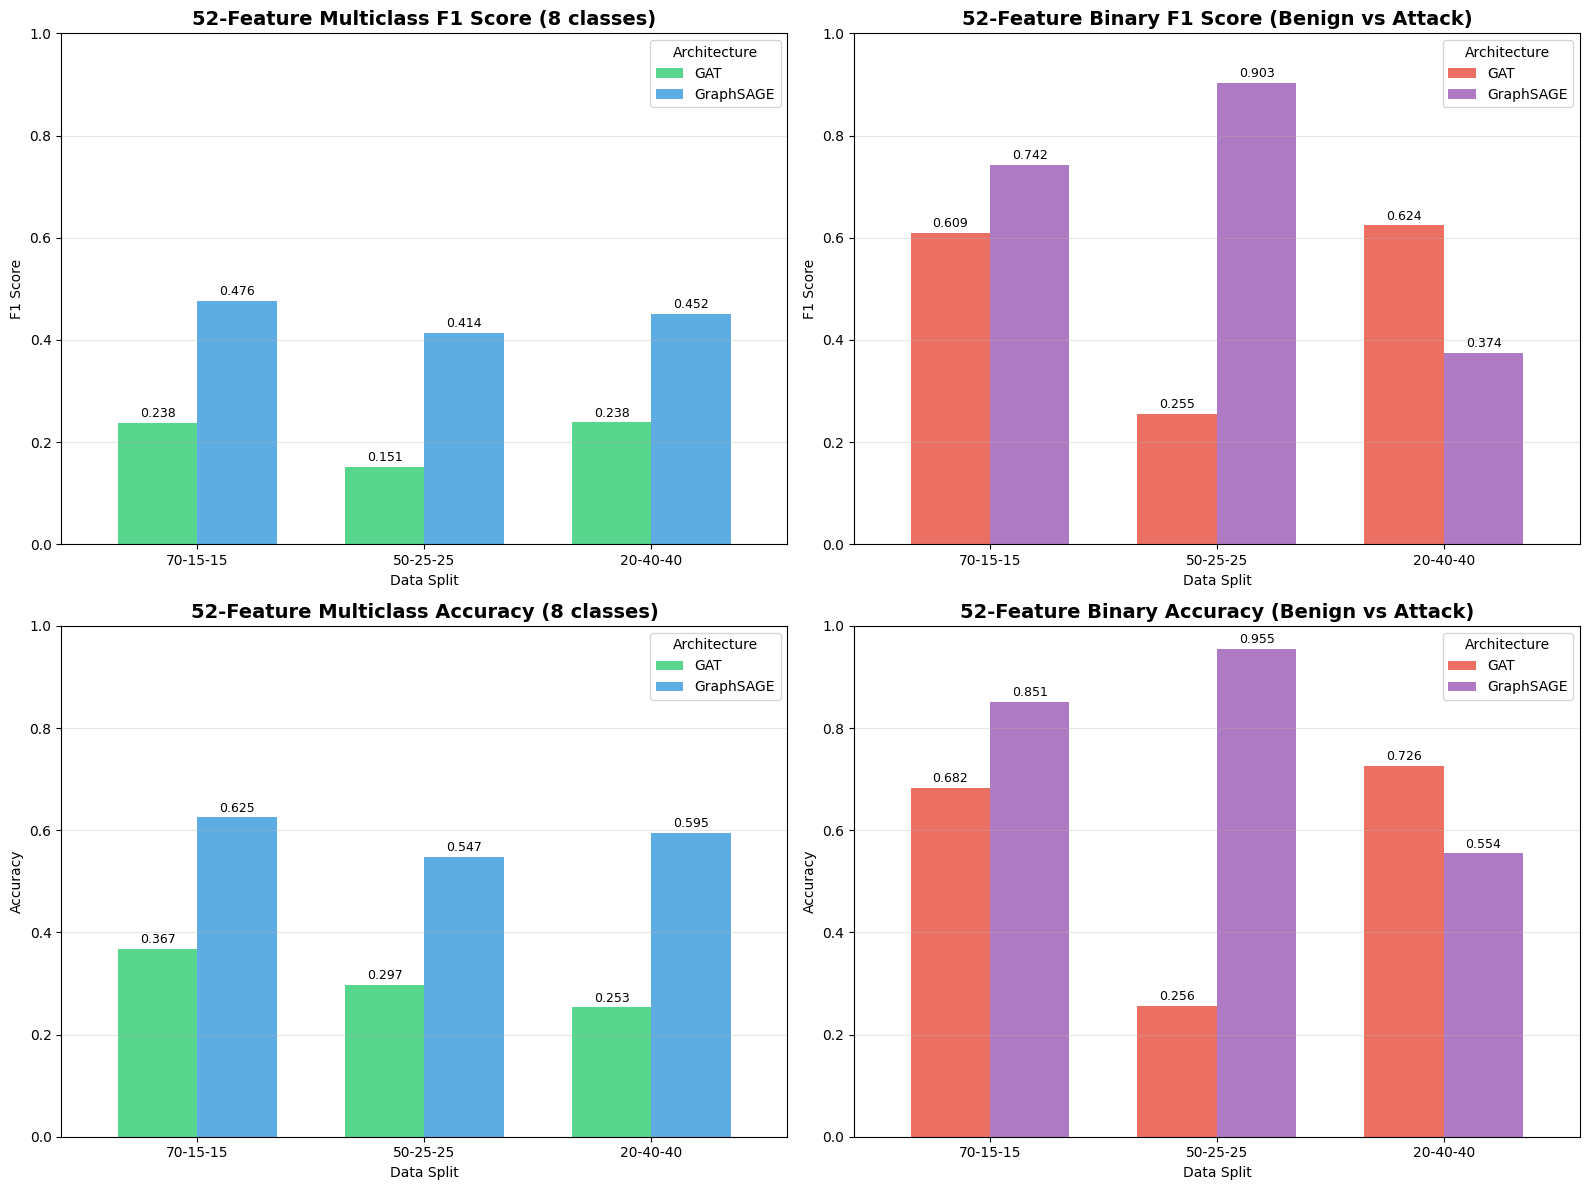


✓ Saved visualization to: models/gnn_12_model_comparison_52.png


In [18]:
# ============================================================================
# 52-FEATURE VISUALIZATION
# ============================================================================

print("="*80)
print("VISUALIZATION - 52-FEATURE 12 MODEL COMPARISON")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

split_order = ['70-15-15', '50-25-25', '20-40-40']

# Plot 1: 52-Feature Multiclass F1 comparison
ax1 = axes[0, 0]
if len(df_multiclass_52) > 0:
    multi_pivot = df_multiclass_52.pivot(index='split', columns='architecture', values='f1')
    multi_pivot = multi_pivot.reindex(split_order)
    multi_pivot.plot(kind='bar', ax=ax1, color=['#2ecc71', '#3498db'], alpha=0.8, width=0.7)
    ax1.set_title('52-Feature Multiclass F1 Score (8 classes)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Data Split')
    ax1.set_ylabel('F1 Score')
    ax1.set_ylim(0, 1)
    ax1.legend(title='Architecture', loc='upper right')
    ax1.set_xticklabels(split_order, rotation=0)
    ax1.grid(True, alpha=0.3, axis='y')
    for container in ax1.containers:
        ax1.bar_label(container, fmt='%.3f', fontsize=9, padding=2)

# Plot 2: 52-Feature Binary F1 comparison
ax2 = axes[0, 1]
if len(df_binary_52) > 0:
    bin_pivot = df_binary_52.pivot(index='split', columns='architecture', values='f1')
    bin_pivot = bin_pivot.reindex(split_order)
    bin_pivot.plot(kind='bar', ax=ax2, color=['#e74c3c', '#9b59b6'], alpha=0.8, width=0.7)
    ax2.set_title('52-Feature Binary F1 Score (Benign vs Attack)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Data Split')
    ax2.set_ylabel('F1 Score')
    ax2.set_ylim(0, 1)
    ax2.legend(title='Architecture', loc='upper right')
    ax2.set_xticklabels(split_order, rotation=0)
    ax2.grid(True, alpha=0.3, axis='y')
    for container in ax2.containers:
        ax2.bar_label(container, fmt='%.3f', fontsize=9, padding=2)

# Plot 3: 52-Feature Multiclass Accuracy comparison
ax3 = axes[1, 0]
if len(df_multiclass_52) > 0:
    multi_acc = df_multiclass_52.pivot(index='split', columns='architecture', values='accuracy')
    multi_acc = multi_acc.reindex(split_order)
    multi_acc.plot(kind='bar', ax=ax3, color=['#2ecc71', '#3498db'], alpha=0.8, width=0.7)
    ax3.set_title('52-Feature Multiclass Accuracy (8 classes)', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Data Split')
    ax3.set_ylabel('Accuracy')
    ax3.set_ylim(0, 1)
    ax3.legend(title='Architecture', loc='upper right')
    ax3.set_xticklabels(split_order, rotation=0)
    ax3.grid(True, alpha=0.3, axis='y')
    for container in ax3.containers:
        ax3.bar_label(container, fmt='%.3f', fontsize=9, padding=2)

# Plot 4: 52-Feature Binary Accuracy comparison
ax4 = axes[1, 1]
if len(df_binary_52) > 0:
    bin_acc = df_binary_52.pivot(index='split', columns='architecture', values='accuracy')
    bin_acc = bin_acc.reindex(split_order)
    bin_acc.plot(kind='bar', ax=ax4, color=['#e74c3c', '#9b59b6'], alpha=0.8, width=0.7)
    ax4.set_title('52-Feature Binary Accuracy (Benign vs Attack)', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Data Split')
    ax4.set_ylabel('Accuracy')
    ax4.set_ylim(0, 1)
    ax4.legend(title='Architecture', loc='upper right')
    ax4.set_xticklabels(split_order, rotation=0)
    ax4.grid(True, alpha=0.3, axis='y')
    for container in ax4.containers:
        ax4.bar_label(container, fmt='%.3f', fontsize=9, padding=2)

plt.tight_layout()
plt.savefig('models/gnn_12_model_comparison_52.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved visualization to: models/gnn_12_model_comparison_52.png")

In [19]:
# ============================================================================
# FINAL COMPARISON: 20-FEATURE vs 52-FEATURE
# ============================================================================

print("="*80)
print("FINAL COMPARISON: 20-FEATURE vs 52-FEATURE")
print("="*80)

# Add feature count to 20-feature results
df_multi_20 = df_multiclass.copy()
df_multi_20['features'] = 20
df_binary_20 = df_binary.copy()
df_binary_20['features'] = 20

# Combine all results
all_multiclass = pd.concat([df_multi_20, df_multiclass_52], ignore_index=True)
all_binary = pd.concat([df_binary_20, df_binary_52], ignore_index=True)

# ============================================================================
# MULTICLASS COMPARISON: 20 vs 52 FEATURES
# ============================================================================
print("\n" + "="*80)
print("MULTICLASS COMPARISON: 20 vs 52 FEATURES")
print("="*80)

print("\n" + "-"*120)
print(f"{'Split':<12} | {'--- 20 Features ---':^40} | {'--- 52 Features ---':^40}")
print(f"{'':12} | {'GAT F1':>10} {'SAGE F1':>10} {'Best':>18} | {'GAT F1':>10} {'SAGE F1':>10} {'Best':>18}")
print("-"*120)

for split in split_order:
    # 20-feature
    gat_20 = df_multi_20[(df_multi_20['split'] == split) & (df_multi_20['architecture'] == 'GAT')]
    sage_20 = df_multi_20[(df_multi_20['split'] == split) & (df_multi_20['architecture'] == 'GraphSAGE')]
    # 52-feature
    gat_52 = df_multiclass_52[(df_multiclass_52['split'] == split) & (df_multiclass_52['architecture'] == 'GAT')]
    sage_52 = df_multiclass_52[(df_multiclass_52['split'] == split) & (df_multiclass_52['architecture'] == 'GraphSAGE')]
    
    if len(gat_20) > 0 and len(sage_20) > 0 and len(gat_52) > 0 and len(sage_52) > 0:
        g20, s20 = gat_20.iloc[0]['f1'], sage_20.iloc[0]['f1']
        g52, s52 = gat_52.iloc[0]['f1'], sage_52.iloc[0]['f1']
        best_20 = 'SAGE' if s20 > g20 else 'GAT'
        best_52 = 'SAGE' if s52 > g52 else 'GAT'
        print(f"{split:<12} | {g20:>10.4f} {s20:>10.4f} {best_20:>18} | {g52:>10.4f} {s52:>10.4f} {best_52:>18}")

print("-"*120)

# ============================================================================
# BINARY COMPARISON: 20 vs 52 FEATURES
# ============================================================================
print("\n" + "="*80)
print("BINARY COMPARISON: 20 vs 52 FEATURES")
print("="*80)

print("\n" + "-"*120)
print(f"{'Split':<12} | {'--- 20 Features ---':^40} | {'--- 52 Features ---':^40}")
print(f"{'':12} | {'GAT F1':>10} {'SAGE F1':>10} {'Best':>18} | {'GAT F1':>10} {'SAGE F1':>10} {'Best':>18}")
print("-"*120)

for split in split_order:
    # 20-feature
    gat_20 = df_binary_20[(df_binary_20['split'] == split) & (df_binary_20['architecture'] == 'GAT')]
    sage_20 = df_binary_20[(df_binary_20['split'] == split) & (df_binary_20['architecture'] == 'GraphSAGE')]
    # 52-feature
    gat_52 = df_binary_52[(df_binary_52['split'] == split) & (df_binary_52['architecture'] == 'GAT')]
    sage_52 = df_binary_52[(df_binary_52['split'] == split) & (df_binary_52['architecture'] == 'GraphSAGE')]
    
    if len(gat_20) > 0 and len(sage_20) > 0 and len(gat_52) > 0 and len(sage_52) > 0:
        g20, s20 = gat_20.iloc[0]['f1'], sage_20.iloc[0]['f1']
        g52, s52 = gat_52.iloc[0]['f1'], sage_52.iloc[0]['f1']
        best_20 = 'SAGE' if s20 > g20 else 'GAT'
        best_52 = 'SAGE' if s52 > g52 else 'GAT'
        print(f"{split:<12} | {g20:>10.4f} {s20:>10.4f} {best_20:>18} | {g52:>10.4f} {s52:>10.4f} {best_52:>18}")

print("-"*120)

# ============================================================================
# SUMMARY STATISTICS
# ============================================================================
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

print("\n📊 Average F1 Scores by Feature Count:")
print("-"*60)
print(f"{'Task':<15} | {'20 Features':>15} | {'52 Features':>15} | {'Winner':>12}")
print("-"*60)

multi_20_avg = df_multi_20['f1'].mean()
multi_52_avg = df_multiclass_52['f1'].mean()
bin_20_avg = df_binary_20['f1'].mean()
bin_52_avg = df_binary_52['f1'].mean()

multi_winner = '52 Features' if multi_52_avg > multi_20_avg else '20 Features'
bin_winner = '52 Features' if bin_52_avg > bin_20_avg else '20 Features'

print(f"{'Multiclass':<15} | {multi_20_avg:>15.4f} | {multi_52_avg:>15.4f} | {multi_winner:>12}")
print(f"{'Binary':<15} | {bin_20_avg:>15.4f} | {bin_52_avg:>15.4f} | {bin_winner:>12}")
print("-"*60)

# Best overall models
print("\n🏆 Best Overall Models:")
print("-"*60)

# Combine all
all_combined = pd.concat([
    df_multi_20.assign(features=20),
    df_multiclass_52,
    df_binary_20.assign(features=20),
    df_binary_52
], ignore_index=True)

best_multi_overall = all_combined[all_combined['task'] == 'multiclass'].loc[
    all_combined[all_combined['task'] == 'multiclass']['f1'].idxmax()
]
best_bin_overall = all_combined[all_combined['task'] == 'binary'].loc[
    all_combined[all_combined['task'] == 'binary']['f1'].idxmax()
]

print(f"Best Multiclass: {best_multi_overall['architecture']} {best_multi_overall['split']} ({int(best_multi_overall['features'])} features)")
print(f"  Accuracy: {best_multi_overall['accuracy']:.4f}, F1: {best_multi_overall['f1']:.4f}")

print(f"\nBest Binary: {best_bin_overall['architecture']} {best_bin_overall['split']} ({int(best_bin_overall['features'])} features)")
print(f"  Accuracy: {best_bin_overall['accuracy']:.4f}, F1: {best_bin_overall['f1']:.4f}")

# Save combined results
all_combined.to_csv('models/all_24_models_comparison.csv', index=False)
print(f"\n✓ Saved combined comparison: models/all_24_models_comparison.csv")

FINAL COMPARISON: 20-FEATURE vs 52-FEATURE

MULTICLASS COMPARISON: 20 vs 52 FEATURES

------------------------------------------------------------------------------------------------------------------------
Split        |           --- 20 Features ---            |           --- 52 Features ---           
             |     GAT F1    SAGE F1               Best |     GAT F1    SAGE F1               Best
------------------------------------------------------------------------------------------------------------------------
70-15-15     |     0.4224     0.7067               SAGE |     0.2382     0.4759               SAGE
50-25-25     |     0.4621     0.7631               SAGE |     0.1507     0.4143               SAGE
20-40-40     |     0.4728     0.7161               SAGE |     0.2383     0.4515               SAGE
------------------------------------------------------------------------------------------------------------------------

BINARY COMPARISON: 20 vs 52 FEATURES

-----------------